In [20]:
from time import time
from pathlib import Path

import torch
from torch import nn
from torch.nn import functional as F
from torchsummary import summary
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [21]:
# arch
PATCH_SIZE = 7  # mnist imgs are 28x28 pixels and one patch size is 7x7=49pixels
# safety check to enusre tha patch size evenly divides the image size
assert 28 % PATCH_SIZE == 0
# nr of patches per image = 28//7=4 square =16 patches = > input tokens
NUM_PATCHES = (28 // PATCH_SIZE)**2
CHANNELS = 1  # grayscale -> equals to 1 channels which is used for setting up the Conv2D-based patch projector
# 10 digits of the MNIST 0-9 and this will be the outputsize of classifier => nn.Linear(d_model, NUM_Classes)@Final layer
NUM_CLASSES = 10


# arch
CONTEXT_SIZE = 64  # what is the maximum context length for predictions?
N_EMBD = 64
NUM_HEADS = 4
NUM_BLOCKS = 4
DROPOUT = 0.0

# training
BATCH_SIZE = 64  # how many independent sequences will we process in parallel?
NUM_EPOCHS = 5
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.1
LEARNING_RATE_DECAY = 0.9
train = True

GET MNIST DATA

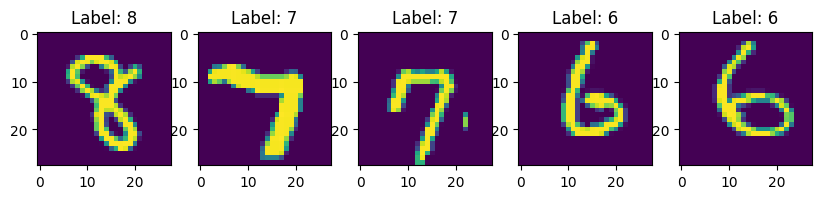

In [22]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # mean and std of mnist data
])

train_dataset = datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=1000, shuffle=False)

# visualize data from dataloader
# it fetches the batches to be used in the next()
data_iter = iter(train_loader)
# fecthes one batch from iterator for images and the coresponding labels
images, labels = next(data_iter)


def imshow(img):
    img = img * 0.3081 + 0.1307  # Unnormalize
    npimg = img.numpy()
    plt.imshow(npimg, cmap='gray')
    plt.axis('off')


fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 2))
for i in range(5):
    ax = axes[i]
    ax.imshow(images[i][0])
    ax.set_title(f'Label: {labels[i].item()}')
plt.show()

PATCH EMBEDDINGS

In [23]:
class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        # example Input of Raw MNIST images (Batch_size=64, Chanel=1, W=28, h=28)
        self._conv2d = nn.Conv2d(
            in_channels=CHANNELS,  # channel=1
            out_channels=N_EMBD,  # n_embd=128 - the dimensional embedding vector
            kernel_size=PATCH_SIZE,  # defines the size of each patch 7x7
            # moves the kernel by 7 pixels = no overlap between patches
            stride=PATCH_SIZE, padding=0)
        # after conv2d each of 16 patches (4x4gid) mapped to 64 features (nr of embeddings)=> (Batch size=64, Emb=64, 4, 4)
        self._flatten = nn.Flatten(start_dim=2, end_dim=3)
        # after flattening we B x 64 x 16

    def forward(self, x):
        x = self._conv2d(x)
        x = self._flatten(x)
        # after permuting the (64,64,4,4) we have (64=Batch,16=patches,64=embedning vector in embedding space) = > Final ViT input: token sequence
        return x.permute(0, 2, 1)

DEMO - Project 4 Patches from 1 image

In [24]:
# Load one image sample
image, label = train_dataset[0]  # one image

# Shape: 1 x 28 x 28 → we add batch dim
image = image.unsqueeze(0)  # B x C x H x W => 1 x 1 x 28 x 28

In [25]:
# Apply PatchingEmbedding
patch_embed = PatchEmbedding()
embedded_patches = patch_embed(image)  # Shape: (1, 16, 64)
print("Embedded patches shape:", embedded_patches.shape)

Embedded patches shape: torch.Size([1, 16, 64])


In [26]:
# : Inspect 1 Patch Vector
# Get the top rows patches of the vector (Patches from 0 to 3)
top_row_vectors = embedded_patches[0][0:4]  # Shape: (4, 64)

# Print each patch vector (rounded for readability)
for i, vector in enumerate(top_row_vectors):
    print(f"\n🔹 Patch {i} vector (shape {vector.shape}):")
    print(torch.round(vector * 1000) / 1000)


🔹 Patch 0 vector (shape torch.Size([64])):
tensor([-0.0770,  0.2010, -0.3080,  0.0920, -0.3740, -0.1580,  0.1990,  0.1710,
         0.3670,  0.2070, -0.0030,  0.5240,  0.0990,  0.4610,  0.2440, -0.0570,
        -0.3670,  0.3470, -0.0740,  0.3550, -0.2710, -0.0910,  0.0340, -0.1230,
         0.1940,  0.3290,  0.0830,  0.0270,  0.2170,  0.2170, -0.2430,  0.1940,
         0.0450, -0.0230,  0.3070, -0.3140, -0.0170, -0.1170, -0.1210,  0.2410,
        -0.0010, -0.5320, -0.0930,  0.1980, -0.1690, -0.2400,  0.2160,  0.2240,
         0.2880,  0.1020, -0.2290, -0.4080,  0.0120,  0.0140, -0.0870,  0.1700,
        -0.1040,  0.4170, -0.1980,  0.3390,  0.2380, -0.4420,  0.0700,  0.4580],
       grad_fn=<DivBackward0>)

🔹 Patch 1 vector (shape torch.Size([64])):
tensor([ 0.6840, -0.1180,  0.4370,  0.0740,  0.3840,  0.0560,  0.0340, -0.2230,
         0.4770,  0.1910, -0.2300,  0.0180,  0.1070,  0.4060, -0.0490,  0.1080,
        -0.2220, -0.3820, -0.2910,  0.5520, -0.2780, -0.3240, -0.2670, -0.1670,


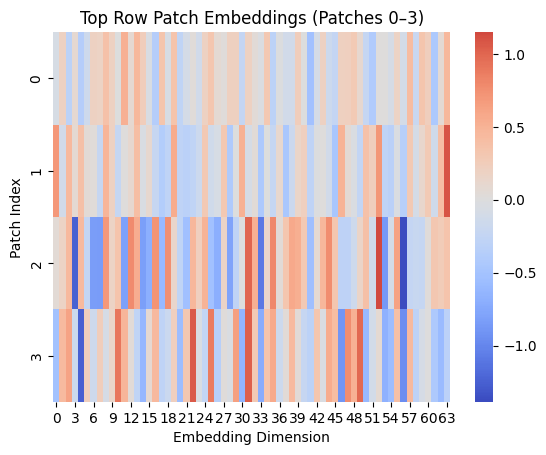

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(top_row_vectors.detach().numpy(), cmap='coolwarm', center=0)
plt.title("Top Row Patch Embeddings (Patches 0–3)")
plt.xlabel("Embedding Dimension")
plt.ylabel("Patch Index")
plt.show()

Add the CLS token

In [ ]:
print(images.shape)

pl = PatchEmbedding()
out = pl(images)
print(out.shape)
# A learnable embedding that acts as a summary token initialized with all 1s just as placeholders(it can be random or zeros)
class_token = nn.Parameter(torch.ones(
    BATCH_SIZE, 1, N_EMBD), requires_grad=True)
# Concatenes the CLS token before the patch embeddings / Shape of cls out is (B,Num_Patches+1,N_Emb)
cls_out = torch.cat([class_token, out], dim=1)
# Now we have [CLS_token, Patch 1, Patch 2, ... Patch 16]

torch.Size([64, 1, 28, 28])
torch.Size([64, 16, 64])


In [29]:
# cls_out is your tensor after concatenation with shape (B, Num_Patches+1, N_Emb)

# Print CLS token (first position)
print("CLS Token:")
print(cls_out[:, 0, :])  # Shape: (B, N_Emb)

# Print first patch (second position, index 1)
print("\nFirst Patch:")
print(cls_out[:, 1, :])  # Shape: (B, N_Emb)

# Print second patch (third position, index 2)
print("\nSecond Patch:")
print(cls_out[:, 2, :])  # Shape: (B, N_Emb)

CLS Token:
tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        ...,
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.]], grad_fn=<SliceBackward0>)

First Patch:
tensor([[ 0.3421, -0.3452,  0.2635,  ...,  0.2001, -0.1288, -0.0036],
        [ 0.3421, -0.3452,  0.2635,  ...,  0.2001, -0.1288, -0.0036],
        [ 0.3421, -0.3452,  0.2635,  ...,  0.2001, -0.1288, -0.0036],
        ...,
        [ 0.3421, -0.3452,  0.2635,  ...,  0.2001, -0.1288, -0.0036],
        [ 0.3421, -0.3452,  0.2635,  ...,  0.2001, -0.1288, -0.0036],
        [ 0.3421, -0.3452,  0.2635,  ...,  0.2001, -0.1288, -0.0036]],
       grad_fn=<SliceBackward0>)

Second Patch:
tensor([[-0.4773, -0.5055,  0.6144,  ..., -0.0851, -0.1058, -1.2178],
        [ 0.3421, -0.3452,  0.2635,  ...,  0.2001, -0.1288, -0.0036],
        [ 0.3421, -0.3452,  0.2635,  ...,  0.2001, -0.1288, -0.0036],
   

ADD POSITIONAL EMBEDDING

In [30]:
# posn_embed is a learnable positional embedding
# (1, num_Patches_1, N-EMB) = Shape
# cls_out + posn_embed = > Adds positional context to the sequence so transformer knows where each token came from
# cls_posn_out = final embedded sequence to feed into Transformer
posn_embed = nn.Parameter(torch.ones(
    1, NUM_PATCHES + 1, N_EMBD), requires_grad=True)
cls_posn_out = cls_out + posn_embed

In [31]:
# cls_posn_out the final embedded sequence to feed in the Transform where embedding and possition is added

# Print CLS token (first position)
print("CLS Token:")
print(cls_posn_out[:, 0, :])  # Shape: (B, N_Emb)

# Print first patch (second position, index 1)
print("\nFirst Patch:")
print(cls_posn_out[:, 1, :])  # Shape: (B, N_Emb)

# Print second patch (third position, index 2)
print("\nSecond Patch:")
print(cls_posn_out[:, 2, :])  # Shape: (B, N_Emb)

CLS Token:
tensor([[2., 2., 2.,  ..., 2., 2., 2.],
        [2., 2., 2.,  ..., 2., 2., 2.],
        [2., 2., 2.,  ..., 2., 2., 2.],
        ...,
        [2., 2., 2.,  ..., 2., 2., 2.],
        [2., 2., 2.,  ..., 2., 2., 2.],
        [2., 2., 2.,  ..., 2., 2., 2.]], grad_fn=<SliceBackward0>)

First Patch:
tensor([[1.3421, 0.6548, 1.2635,  ..., 1.2001, 0.8712, 0.9964],
        [1.3421, 0.6548, 1.2635,  ..., 1.2001, 0.8712, 0.9964],
        [1.3421, 0.6548, 1.2635,  ..., 1.2001, 0.8712, 0.9964],
        ...,
        [1.3421, 0.6548, 1.2635,  ..., 1.2001, 0.8712, 0.9964],
        [1.3421, 0.6548, 1.2635,  ..., 1.2001, 0.8712, 0.9964],
        [1.3421, 0.6548, 1.2635,  ..., 1.2001, 0.8712, 0.9964]],
       grad_fn=<SliceBackward0>)

Second Patch:
tensor([[ 0.5227,  0.4945,  1.6144,  ...,  0.9149,  0.8942, -0.2178],
        [ 1.3421,  0.6548,  1.2635,  ...,  1.2001,  0.8712,  0.9964],
        [ 1.3421,  0.6548,  1.2635,  ...,  1.2001,  0.8712,  0.9964],
        ...,
        [ 0.8750,  0.6801,

SELF ATTENTION - PERFORMS THE SCALED DOT-PRODUCT SELF-Attention

In [32]:
class AttentionHead(nn.Module):  # Head
    """ one head of self-attention """
    # Constructor

    def __init__(self, head_size, is_decoder):
        super().__init__()
        # we take the input tensor x (shape: B x T x N_Embd=sequence of tokens) and project it into k, q and v (keys, queries and values each with shape B x T, Head_Size)
        # The projections are learned linear transformation of the same input
        # learned linear layer without bias where x @ Weigh key matrix (emb_dim=64, head_size=16)
        self.key = nn.Linear(N_EMBD, head_size, bias=False)
        # learned linear layer without bias where x @ Weigh query matrix (emb_dim=64, head_size=16)
        self.query = nn.Linear(N_EMBD, head_size, bias=False)
        # learned linear layer without bias where x @ Weigh value matrix (emb_dim=64, head_size=16)
        self.value = nn.Linear(N_EMBD, head_size, bias=False)
        self.register_buffer('tril', torch.tril(  # trils is a lower triangular matrix used for masking future tokens in decoder self-attebtion, not needed in Vit or encoder
            torch.ones(CONTEXT_SIZE, CONTEXT_SIZE)))  # shape is T, T
        self.dropout = nn.Dropout(DROPOUT)
        self._is_decoder = is_decoder

    def forward(self, x):  # Self attention magic were we are transforming K and Q in key and query matrices(each patch in the sequence gets mapped to a query, key, value vectors)
        B, T, C = x.shape
        # k and q are used to calculate attention scores and v is what gets aggregated and passed forward based on attention scores
        k = self.key(x)   # SHAPE(B T C)
        q = self.query(x)  # SHAPE(B T C)
        # compute attention scores ("affinities") where q @ k.transpose(-2,-1) is the attention score between every token pair and * C**-0.5 it normalizes large dot products
        # (B, T, C) @ (B, C, T) -> (B, T, T)
        # This is the attention matrix where each row tells how much attention one token pays to all others
        wei = q @ k.transpose(-2, -1) * C**-0.5
        if self._is_decoder:  # only in decoder blocks
            wei = wei.masked_fill(
                self.tril[:T, :T] == 0, float('-inf'))  # (B, T, T)
        # (B, T, T) # converts attention scores into probabilities/now every row sums to 1 and this is were we "pay attention"
        wei = F.softmax(wei, dim=-1)
        # randomly drops some attention weights to regularize
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        # SHAPE(B T C) # Value projections (gets aggregated and passed forward based on attention scores)
        v = self.value(x)
        # (B, T, T) @ (B, T, C) -> (B, T, C) weighed average of the values => each token becomes blen of other's token values, weighted by how much attention it paid
        out = wei @ v
        return out  # (B, T, head_size)

Multi-Head Attention (Multiple heads whre a tiny MNIST Vit can have 4 heads where head size per head is 64 (embeding dim divided by 4 heads = 16))

Each attention head learns to attend to different parts of the sequece, and the model combines their outputs

So that class should Concatanate -> Linear Projection-> Output

In [ ]:
# 4 heads where the head size per head is 16 (Embed dim/num of heads)
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """
    # Constructor where head_size is the dimensionality of each individual attention head 16 and is_decoder whether to use the masking for decoder attention

    def __init__(self, head_size, is_decoder=True):
        super().__init__()
        # Create attention heads NUM_HEADS parallel attention heads and each Head gets head_size(as its projection dim) and a key\value\query triplet inside
        self.heads = nn.ModuleList(
            [AttentionHead(head_size, is_decoder) for _ in range(NUM_HEADS)])
        # Output projection concatenes all head outputs Shape (B, T, head_size*Num_heads) which results in (B,R,N_Emb) as head_size*Num_heads
        # this projection helps the model re-integrate information from different heads
        self.proj = nn.Linear(head_size * NUM_HEADS, N_EMBD)
        # droput for regularisation and to prevent overfitting - it is aplied to the final projection output
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x):
        # for each attention Head h, it computes attention on x. Each head returs shape (B, T, head_size) and the concat output is (B, T, head_size*num_heads)
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        # project back to N_Embed (B, T, N_embed) reblended the multiple heads into a single representation per token
        out = self.proj(out)
        out = self.dropout(out)  # regularization
        # It has the same shape as the input, but each token is now contextually enriched by all the others (via attention
        return out

MLP - FeedForward layer (nn.Linear(64,10))

In [34]:
class MLP(nn.Module):  # FeedForward where clasification takes place
    """ a simple linear layer followed by a non-linearity """

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # first fully connected layer. Expands the feature space (eg from 64 to 256) allowing the network to learn more complex intermediate represenations
            nn.Linear(N_EMBD, 4 * N_EMBD),
            nn.GELU(),  # ViT paper uses GELU # Activation fuctions -Adds non-linearity
            # Projects back down to original embedding dim eg 256 ->64
            nn.Linear(4 * N_EMBD, N_EMBD),
            nn.Dropout(DROPOUT),
        )

    def forward(self, x):
        # passes the input x of shape B x T x N-Embed through the MLP block. Output has the same shape
        return self.net(x)

INSPECT SHAPES of Patch Empeddings, CLS_OUT, CLS_POS, MULTI HEAD ATTENTION and and MLP

In [35]:
# Step 1: Original image shape
# e.g., torch.Size([32, 1, 28, 28])
print(f"Input image batch shape: {images.shape}")

# Step 2: Patch embedding
pl = PatchEmbedding()
out = pl(images)  # (B, NUM_PATCHES, N_EMBD)
# e.g., torch.Size([32, 16, 64])
print(f"Patch Embedding output shape: {out.shape}")

# Step 3: Add [CLS] token (cf. ViT Eqn 1)
class_token = nn.Parameter(
    # images.size(0) = BATCH_SIZE
    torch.ones(images.size(0), 1, N_EMBD), requires_grad=True
)
# Shape: (B, NUM_PATCHES + 1, N_EMBD)
cls_out = torch.cat([class_token, out], dim=1)
# e.g., torch.Size([32, 17, 64])
print(f"With [CLS] token shape: {cls_out.shape}")

# Step 4: Add positional embeddings
posn_embed = nn.Parameter(
    torch.ones(1, NUM_PATCHES + 1, N_EMBD), requires_grad=True
)
cls_posn_out = cls_out + posn_embed
# e.g., torch.Size([32, 17, 64])
print(f"After adding positional embeddings: {cls_posn_out.shape}")

# Step 5: Apply Multi-Head Self-Attention
msa = MultiHeadAttention(N_EMBD // NUM_HEADS, is_decoder=False)
msa_out = msa(cls_posn_out)
# e.g., torch.Size([32, 17, 64])
print(f"Output after Multi-Head Attention: {msa_out.shape}")

# Step 6: Apply MLP block
mlp = MLP()
mlp_out = mlp(msa_out)
print(f"Output after MLP: {mlp_out.shape}")  # e.g., torch.Size([32, 17, 64])

Input image batch shape: torch.Size([64, 1, 28, 28])
Patch Embedding output shape: torch.Size([64, 16, 64])
With [CLS] token shape: torch.Size([64, 17, 64])
After adding positional embeddings: torch.Size([64, 17, 64])
Output after Multi-Head Attention: torch.Size([64, 17, 64])
Output after MLP: torch.Size([64, 17, 64])


TRANSFORMER ENCODER BLOCK


In [36]:
# Define TransformerEncoder Block

class TransformerBlock(nn.Module):  # Block
    """ Transformer block: communication followed by computation """

    def __init__(self, is_decoder=True):
        # N_EMBD: embedding dimension, NUM_HEADS: the number of heads we'd like
        super().__init__()
        head_size = N_EMBD // NUM_HEADS
        self.mha = MultiHeadAttention(head_size, is_decoder)
        self.mlp = MLP()
        self.ln1 = nn.LayerNorm(N_EMBD)
        self.ln2 = nn.LayerNorm(N_EMBD)

    def forward(self, x):
        # cf eqn 2, 3 of ViT paper
        x = x + self.mha(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

VISION TRANSFORMER

In [39]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'


class VisualTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self._token_embed = PatchEmbedding()
        self._class_embed = nn.Parameter(
            torch.randn(1, 1, N_EMBD), requires_grad=True)
        self._posn_embed = nn.Embedding(NUM_PATCHES + 1, N_EMBD)

        self.blocks = nn.Sequential(
            *[TransformerBlock(is_decoder=False) for _ in range(NUM_BLOCKS)])
        self.ln_f = nn.LayerNorm(N_EMBD)  # final layer norm
        self.classifier = nn.Linear(N_EMBD, NUM_CLASSES)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, x, y=None):
        token_embed = self._token_embed(x)  # B T C
        class_token = self._class_embed.expand(BATCH_SIZE, -1, -1)
        token_embed = torch.cat([class_token, token_embed], dim=1)
        posn_embed = self._posn_embed(torch.arange(
            NUM_PATCHES + 1, device=device))  # T C
        x = token_embed + posn_embed  # B T C
        x = self.blocks(x)
        # cf eqn 4 in ViT paper
        x = x[:, 0]  # B T C -> B C
        x = self.ln_f(x)
        logits = self.classifier(x)

        loss = None
        if y is not None:
            loss = F.cross_entropy(logits, y)

        return logits, loss


model = VisualTransformer()

TRAINING LOOP

c:\MLX\week3\mnist_transformer\venv\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Steps 0 | Loss: 0.7136 | Accuracy: 76.56%
Steps 100 | Loss: 0.6530 | Accuracy: 75.00%
Steps 200 | Loss: 0.6899 | Accuracy: 76.56%
Steps 300 | Loss: 0.5504 | Accuracy: 82.81%
Steps 400 | Loss: 0.5173 | Accuracy: 85.94%
Steps 500 | Loss: 0.4653 | Accuracy: 82.81%
Steps 600 | Loss: 0.3537 | Accuracy: 93.75%
Steps 700 | Loss: 0.4077 | Accuracy: 87.50%
Steps 800 | Loss: 0.4431 | Accuracy: 85.94%
Steps 900 | Loss: 0.3791 | Accuracy: 89.06%
Steps 0 | Loss: 0.4715 | Accuracy: 84.38%
Steps 100 | Loss: 0.7997 | Accuracy: 73.44%
Steps 200 | Loss: 0.4103 | Accuracy: 87.50%
Steps 300 | Loss: 0.4267 | Accuracy: 87.50%
Steps 400 | Loss: 0.5568 | Accuracy: 84.38%
Steps 500 | Loss: 0.5127 | Accuracy: 87.50%
Steps 600 | Loss: 0.4110 | Accuracy: 85.94%
Steps 700 | Loss: 0.4179 | Accuracy: 87.50%
Steps 800 | Loss: 0.3195 | Accuracy: 92.19%
Steps 900 | Loss: 0.4830 | Accuracy: 84.38%
Steps 0 | Loss: 0.4437 | Accuracy: 82.81%
Steps 100 | Loss: 0.5008 | Accuracy: 84.38%
Steps 200 | Loss: 0.3137 | Accuracy: 9

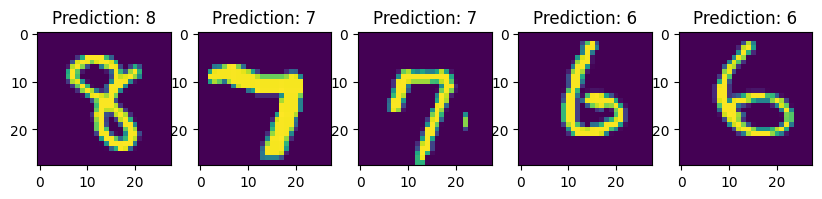

In [42]:
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimizer, gamma=LEARNING_RATE_DECAY)
start_t = time()

for i in range(NUM_EPOCHS):
    for steps, (X, y) in enumerate(train_loader):
        X, y = X.to(device), y.to(device)
        if X.size(0) != BATCH_SIZE:
            print(f"Skipping batch {steps} with size {X.size(0)}")
            continue

        if not train:
            break

        logits, loss = model(X, y)
        # Compute accuracy
        preds = torch.argmax(logits, dim=1)
        correct = (preds == y).sum().item()
        accuracy = correct/BATCH_SIZE

        if steps % 100 == 0:
            scheduler.step()
            print(
                f"Steps {steps} | Loss: {loss.item():.4f} | Accuracy: {accuracy*100:.2f}%")

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

if train:
    torch.save(model.state_dict(), f"Vit.model")
state_dict = torch.load("Vit.model")
model.load_state_dict(state_dict)
print(f"Took {round(time() - start_t)}s")

# inference
pred, _ = model(images)
probs = torch.softmax(pred, dim=1)
label = torch.argmax(probs, dim=1)
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 2))
for i in range(0, 5):
    ax = axes[i]
    i = i + 0
    ax.imshow(images[i][0])
    ax.set_title(f'Prediction: {label[i]}')
plt.show()